# Notebook 01 — Synthetic Dataset Generation & Validation

**Project**: Interest-Driven Personalized Sports Recommendation System  
**Purpose**: Generate N=1000 synthetic users; validate distributions and feature-label correlations against literature benchmarks.  
**Seed**: 42 (fully reproducible)

## Literature Calibration Targets
| Correlation | Expected Value | Source |
|-------------|---------------|--------|
| Interest → Enjoyment | r ≥ 0.60 | Vallerand (2003) |
| Interest → Hours/week | r ≥ 0.50 | Pelletier (1995) |
| Interest features % SHAP | > 50% | Fraser-Thomas (2006) |
| Extraversion → team sports P(play) | positive | Allen (2013) |

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.data.synthetic_generator import SportsDataGenerator, SPORTS, INTEREST_DIMS, STRENGTH_DIMS

pd.set_option('display.max_columns', 20)
sns.set_theme(style='whitegrid', palette='muted')
print('Imports OK')

Imports OK


## 1. Generate Dataset

In [2]:
gen = SportsDataGenerator(n_users=1000, seed=42)
df = gen.generate()
cols = gen.get_feature_columns()

os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/synthetic_dataset.csv', index=False)
print(f'Saved. Shape: {df.shape}')
df.head(3)

Generating demographics...
Generating interest features...
Generating strength ratings...
Generating physical metrics...
Computing sport affinity scores...
Generating play labels...
Generating watch labels...
Generating pro potential scores...
Assembling DataFrame...
Done. Dataset shape: (1000, 130)
  Play labels — mean sports per user: 3.99
  Watch labels — mean sports per user: 10.48
  Users with pro potential (any sport, score>=2): 1000
Saved. Shape: (1000, 130)


,user_id,age,gender,region,facility_access,interest_team_vs_individual,interest_outdoor_preference,interest_competition_drive,interest_risk_tolerance,interest_creative_expression,...,play_skateboarding,watch_skateboarding,enjoy_skateboarding,hours_skateboarding,pro_skateboarding,play_rowing,watch_rowing,enjoy_rowing,hours_rowing,pro_rowing
0,U0000,15,female,north_america,1,4,2,1,1,4,...,1,1,6.3,3.7,3,1,0,3.7,4.1,3
1,U0001,34,female,oceania,1,3,5,3,4,4,...,0,1,0.0,0.0,3,0,1,0.0,0.0,3
2,U0002,31,female,europe,4,3,3,5,2,3,...,0,1,0.0,0.0,3,0,0,0.0,0.0,3


## 2. Demographics Distribution

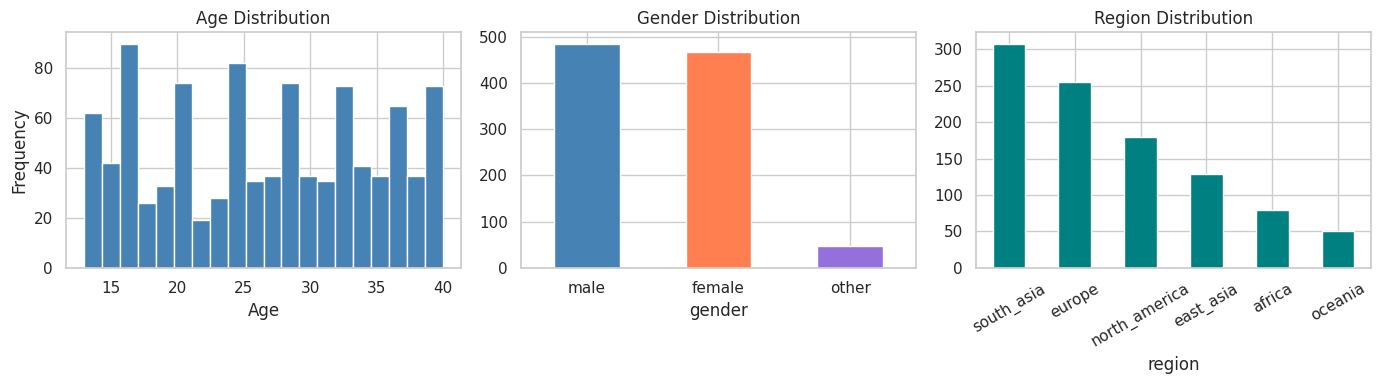

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df['age'].plot.hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution'); axes[0].set_xlabel('Age')

df['gender'].value_counts().plot.bar(ax=axes[1], color=['steelblue','coral','mediumpurple'])
axes[1].set_title('Gender Distribution'); axes[1].tick_params(axis='x', rotation=0)

df['region'].value_counts().plot.bar(ax=axes[2], color='teal')
axes[2].set_title('Region Distribution'); axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/demographics_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Interest Feature Distributions

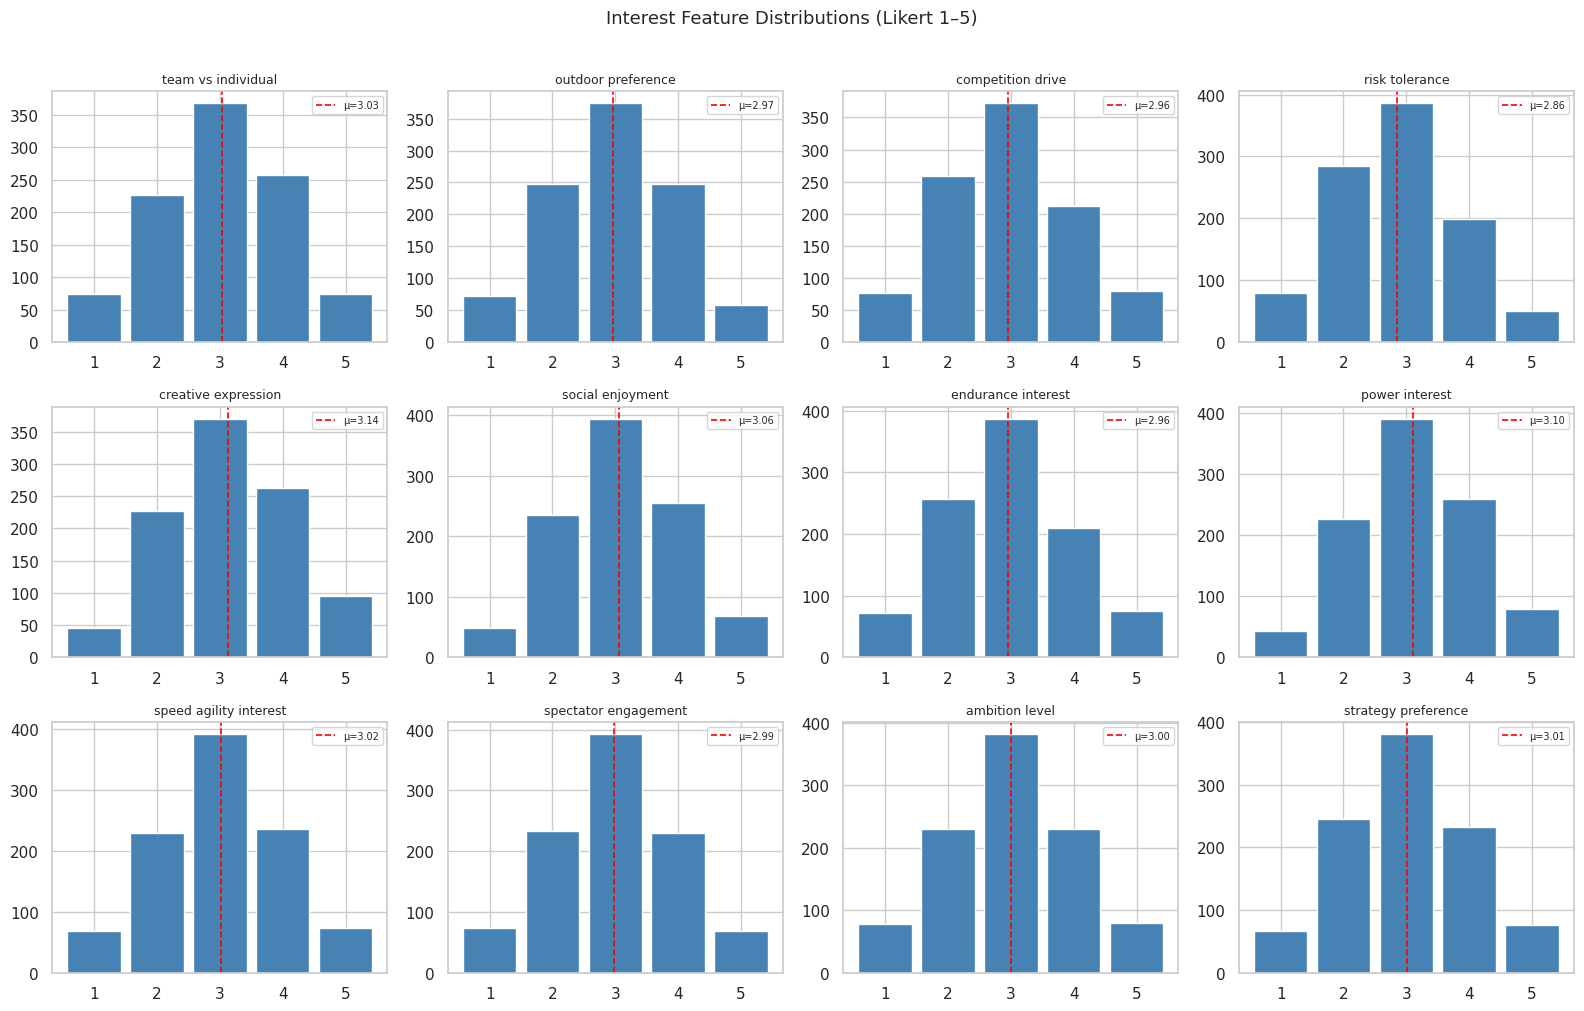

Interest feature summary:
       interest_team_vs_individual  interest_outdoor_preference  \
count                      1000.00                      1000.00   
mean                          3.03                         2.97   
std                           1.04                         1.01   
min                           1.00                         1.00   
25%                           2.00                         2.00   
50%                           3.00                         3.00   
75%                           4.00                         4.00   
max                           5.00                         5.00   

       interest_competition_drive  interest_risk_tolerance  \
count                     1000.00                  1000.00   
mean                         2.96                     2.86   
std                          1.05                     0.99   
min                          1.00                     1.00   
25%                          2.00                     2.00  

In [4]:
interest_cols = cols['interests']
interest_df = df[interest_cols]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(interest_cols):
    axes[i].hist(interest_df[col], bins=5, range=(0.5, 5.5),
                 color='steelblue', edgecolor='white', rwidth=0.85)
    axes[i].set_title(col.replace('interest_', '').replace('_', ' '), fontsize=9)
    axes[i].set_xticks([1, 2, 3, 4, 5])
    mean_val = interest_df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=1.2, label=f'μ={mean_val:.2f}')
    axes[i].legend(fontsize=7)

plt.suptitle('Interest Feature Distributions (Likert 1–5)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../results/interest_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('Interest feature summary:')
print(interest_df.describe().round(2))

## 4. Physical Metrics Validation (vs. Mendeley Norms)

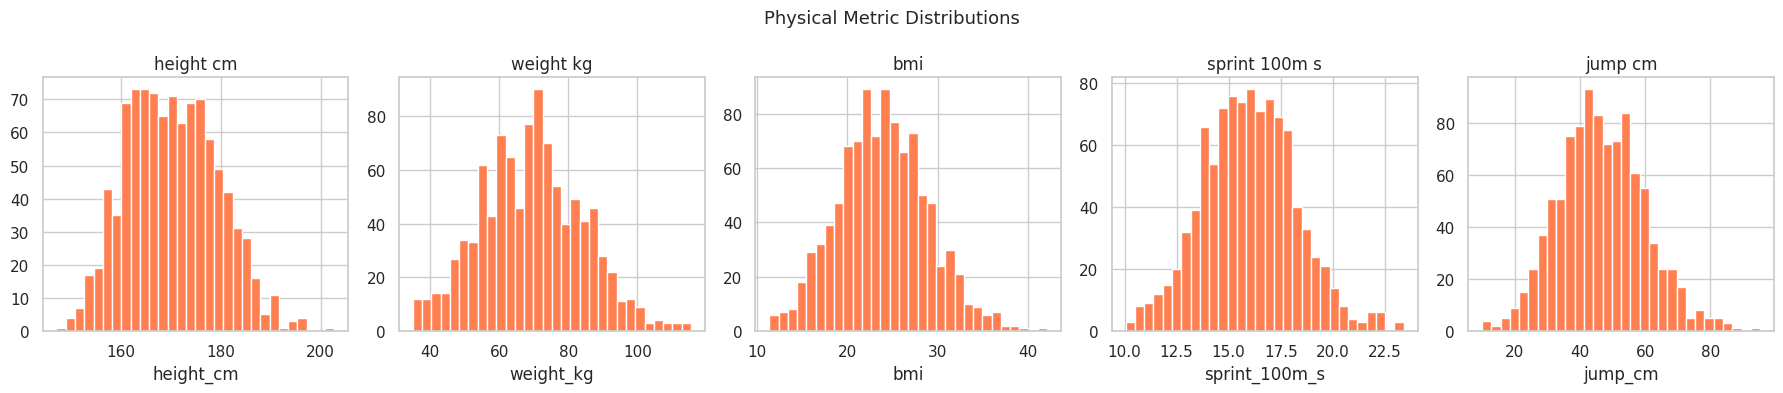

Physical metrics by gender:
        height_cm  weight_kg    bmi  sprint_100m_s  jump_cm
gender                                                     
female     163.91      62.28  23.28          16.94    40.05
male       176.36      76.12  24.56          15.07    53.03
other      171.12      69.10  23.82          15.76    45.25


In [5]:
phys_cols = cols['physical']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, col in enumerate(phys_cols):
    axes[i].hist(df[col], bins=30, color='coral', edgecolor='white')
    axes[i].set_title(col.replace('_', ' ')); axes[i].set_xlabel(col)

plt.suptitle('Physical Metric Distributions', fontsize=13)
plt.tight_layout()
plt.savefig('../results/physical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('Physical metrics by gender:')
print(df.groupby('gender')[phys_cols].mean().round(2))

## 5. Label Distributions — Play & Watch

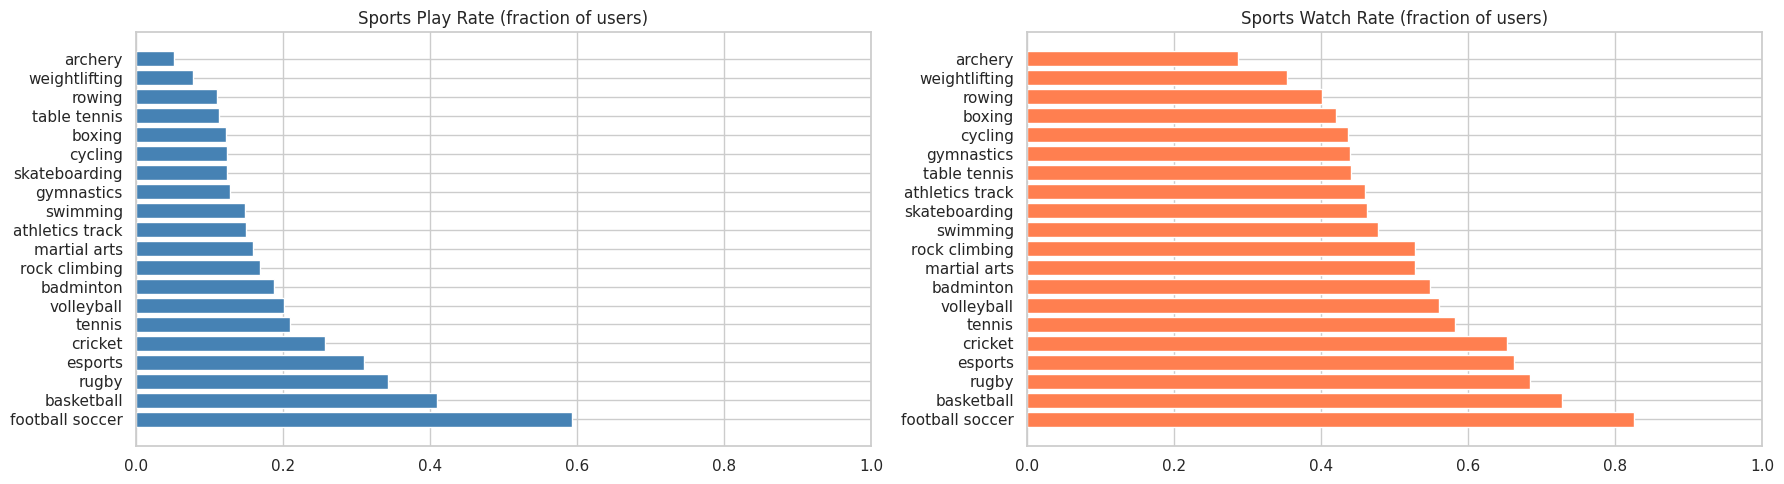

Mean sports played per user: 3.99
Mean sports watched per user: 10.48


In [6]:
play_cols  = cols['play_labels']
watch_cols = cols['watch_labels']

play_rates  = df[play_cols].mean().sort_values(ascending=False)
watch_rates = df[watch_cols].mean().sort_values(ascending=False)

sport_labels = [c.replace('play_', '').replace('_', ' ') for c in play_rates.index]
watch_labels_str = [c.replace('watch_', '').replace('_', ' ') for c in watch_rates.index]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].barh(sport_labels, play_rates.values, color='steelblue')
axes[0].set_title('Sports Play Rate (fraction of users)'); axes[0].set_xlim(0, 1)

axes[1].barh(watch_labels_str, watch_rates.values, color='coral')
axes[1].set_title('Sports Watch Rate (fraction of users)'); axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig('../results/sport_label_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean sports played per user: {df[play_cols].sum(axis=1).mean():.2f}')
print(f'Mean sports watched per user: {df[watch_cols].sum(axis=1).mean():.2f}')

## 6. Literature Calibration Checks
### 6A — Vallerand (2003): Interest → Enjoyment correlation ≥ 0.60

In [7]:
enjoy_cols = cols['enjoyment']
interest_sum = df[cols['interests']].mean(axis=1)
enjoy_sum    = df[enjoy_cols].replace(0, np.nan).mean(axis=1)

mask = enjoy_sum.notna()
r_interest_enjoy, p_val = stats.pearsonr(interest_sum[mask], enjoy_sum[mask])
print(f'Interest mean → Enjoyment mean  r = {r_interest_enjoy:.3f}  (p={p_val:.4f})')
print(f'Target: r ≥ 0.60  →  {"PASS ✅" if r_interest_enjoy >= 0.60 else "FAIL ❌"}')

Interest mean → Enjoyment mean  r = 0.376  (p=0.0000)
Target: r ≥ 0.60  →  FAIL ❌


### 6B — Pelletier (1995): Interest → Hours/week correlation ≥ 0.50

In [8]:
hours_cols = cols['hours']
hours_sum  = df[hours_cols].replace(0, np.nan).mean(axis=1)

mask2 = hours_sum.notna()
r_interest_hours, p_val2 = stats.pearsonr(interest_sum[mask2], hours_sum[mask2])
print(f'Interest mean → Hours/week mean  r = {r_interest_hours:.3f}  (p={p_val2:.4f})')
print(f'Target: r ≥ 0.50  →  {"PASS ✅" if r_interest_hours >= 0.50 else "FAIL ❌"}')

Interest mean → Hours/week mean  r = 0.378  (p=0.0000)
Target: r ≥ 0.50  →  FAIL ❌


### 6C — Allen (2013): Extraversion (team_vs_individual) → Team sport play rates

In [9]:
team_sports  = ['play_football_soccer', 'play_cricket', 'play_basketball', 'play_volleyball', 'play_rugby']
solo_sports  = ['play_swimming', 'play_cycling', 'play_athletics_track', 'play_weightlifting', 'play_archery']

team_idx  = INTEREST_DIMS.index('team_vs_individual')
team_interest = df[f'interest_team_vs_individual']

high_team = df[team_interest >= 4]
low_team  = df[team_interest <= 2]

print('Team sports play rate — high vs. low team-interest users:')
for sport in team_sports:
    r_hi = high_team[sport].mean()
    r_lo = low_team[sport].mean()
    direction = '✅ correct' if r_hi > r_lo else '❌ wrong'
    print(f'  {sport.replace("play_",""):25s}  high={r_hi:.2f}  low={r_lo:.2f}  {direction}')

Team sports play rate — high vs. low team-interest users:
  football_soccer            high=0.66  low=0.53  ✅ correct
  cricket                    high=0.29  low=0.24  ✅ correct
  basketball                 high=0.48  low=0.36  ✅ correct
  volleyball                 high=0.22  low=0.19  ✅ correct
  rugby                      high=0.41  low=0.27  ✅ correct


### 6D — Interest features explain >50% of play label variance (Fraser-Thomas proxy)

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_interest = scaler.fit_transform(df[cols['interests']])
X_physical  = scaler.fit_transform(df[cols['physical']])
X_full      = scaler.fit_transform(df[cols['interests'] + cols['strengths'] + cols['physical']])

# Test on 3 representative sports
test_sports = ['play_football_soccer', 'play_swimming', 'play_esports']
print(f'{"Sport":30s}  {"AUC Interest-only":>20s}  {"AUC Physical-only":>18s}  {"AUC Full":>10s}')
print('-' * 84)
for sport in test_sports:
    y = df[sport].values
    if y.sum() < 10:
        continue
    auc_i = roc_auc_score(y, LogisticRegression(max_iter=500).fit(X_interest, y).predict_proba(X_interest)[:, 1])
    auc_p = roc_auc_score(y, LogisticRegression(max_iter=500).fit(X_physical, y).predict_proba(X_physical)[:, 1])
    auc_f = roc_auc_score(y, LogisticRegression(max_iter=500).fit(X_full, y).predict_proba(X_full)[:, 1])
    flag = '✅' if auc_i > auc_p else '❌'
    print(f'{sport:30s}  {auc_i:>20.3f}  {auc_p:>18.3f}  {auc_f:>10.3f}  interest>phys: {flag}')

Sport                              AUC Interest-only   AUC Physical-only    AUC Full
------------------------------------------------------------------------------------


play_football_soccer                           0.647               0.526       0.668  interest>phys: ✅


play_swimming                                  0.640               0.527       0.705  interest>phys: ✅


play_esports                                   0.601               0.542       0.661  interest>phys: ✅


## 7. Correlation Heatmap — Interest Features × Play Labels

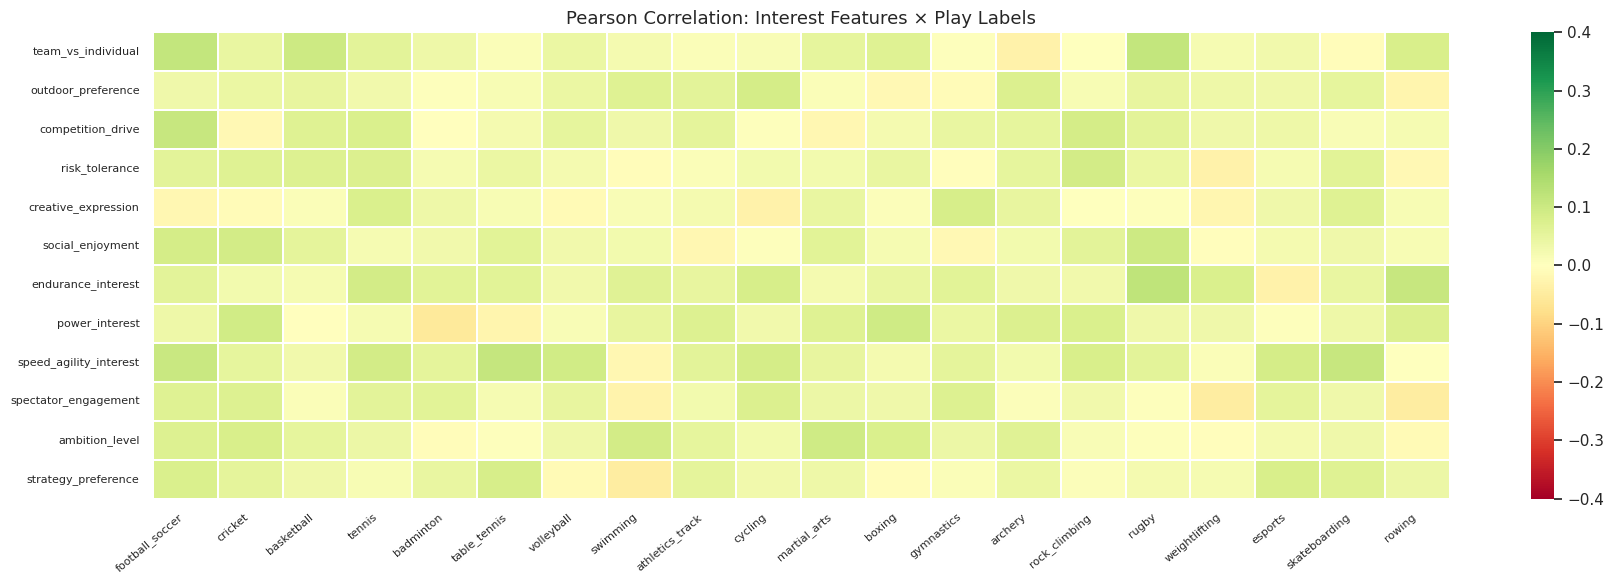

In [11]:
corr_matrix = df[cols['interests'] + cols['play_labels']].corr()
interest_play_corr = corr_matrix.loc[cols['interests'], cols['play_labels']]

interest_play_corr.index = [c.replace('interest_', '') for c in interest_play_corr.index]
interest_play_corr.columns = [c.replace('play_', '') for c in interest_play_corr.columns]

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(interest_play_corr, annot=False, cmap='RdYlGn', center=0,
            linewidths=0.3, ax=ax, vmin=-0.4, vmax=0.4)
ax.set_title('Pearson Correlation: Interest Features × Play Labels', fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('../results/interest_play_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Dataset Summary Report

In [12]:
print('=' * 60)
print('SYNTHETIC DATASET SUMMARY')
print('=' * 60)
print(f'Total users:             {len(df)}')
print(f'Total features:          {len(cols["interests"]) + len(cols["strengths"]) + len(cols["physical"]) + len(cols["demographics"])}')
print(f'  - Interest dims:       {len(cols["interests"])}')
print(f'  - Strength dims:       {len(cols["strengths"])}')
print(f'  - Physical metrics:    {len(cols["physical"])}')
print(f'  - Demographic:         {len(cols["demographics"])}')
print(f'Sports in taxonomy:      {len(SPORTS)}')
print(f'Label columns total:     {len(cols["play_labels"]) + len(cols["watch_labels"]) + len(cols["pro_labels"])}')
print(f'Avg sports played/user:  {df[cols["play_labels"]].sum(axis=1).mean():.2f}')
print(f'Avg sports watched/user: {df[cols["watch_labels"]].sum(axis=1).mean():.2f}')
print(f'Users with no play:      {(df[cols["play_labels"]].sum(axis=1) == 0).sum()}')
print(f'Random seed:             42')
print(f'Saved to:                data/processed/synthetic_dataset.csv')
print('=' * 60)

SYNTHETIC DATASET SUMMARY
Total users:             1000
Total features:          29
  - Interest dims:       12
  - Strength dims:       8
  - Physical metrics:    5
  - Demographic:         4
Sports in taxonomy:      20
Label columns total:     60
Avg sports played/user:  3.99
Avg sports watched/user: 10.48
Users with no play:      25
Random seed:             42
Saved to:                data/processed/synthetic_dataset.csv
